In [1]:
# you may need to run these on fresh dev container 
# uv sync #install deps
# uv run python -m ipykernel install --user --name capstone


In [2]:
import polars as pl
import os
import matplotlib.pyplot as plt
from datetime import date


## Are we accurately matching deps repos to scorecards?

Initial testing found ~19k scorecards were availabe, out of ~47k repos from deps.dev (1 package, pypi, github)


In [3]:
# load all unique packages from parquet file
dfrepolst = pl.read_parquet("../../data/augmented_data/unique_packages.parquet")

In [4]:
dfrepolst.head()

package_name,github_repo,min_snapshot_date,max_snapshot_date
str,str,datetime[μs],datetime[μs]
"""utt""","""github.com/larose/utt""",2025-12-01 21:00:50.611233,2026-02-23 21:00:56.375217
"""seleniumuser""","""github.com/matt-manes/selenium…",2023-04-10 21:01:49.219309,2026-02-23 21:00:56.375217
"""feast-cassandra""","""github.com/datastaxdevs/feast-…",2024-07-01 21:00:42.720159,2026-02-23 21:00:56.375217
"""meta-screening""","""github.com/meta-trial/meta-scr…",2023-04-10 21:01:49.219309,2026-02-23 21:00:56.375217
"""werkflow""","""github.com/adalundhe/werkflow""",2025-04-22 01:04:30.709280,2026-02-23 21:00:56.375217


In [5]:
# load scorecard dataset from multiple parquet files
scorecard_dir = "../../data/source_data/pypi_scorecards/"
scorecard_files = [f for f in os.listdir(scorecard_dir) if f.endswith(".parquet")]


#scorecard_dfs = [pl.read_parquet(os.path.join(scorecard_dir, f)) for f in scorecard_files]
scorecards_dfs = []
for f in scorecard_files:
    print(f"Loading {f}...")
    df = pl.read_parquet(os.path.join(scorecard_dir, f))
    scorecards_dfs.append(df)
    
scorecard_df = pl.concat(scorecards_dfs)
scorecards_dfs = []


Loading pypi-scorecards-20260307-000000000007.parquet...
Loading pypi-scorecards-20260307-000000000006.parquet...
Loading pypi-scorecards-20260307-000000000004.parquet...
Loading pypi-scorecards-20260307-000000000005.parquet...
Loading pypi-scorecards-20260307-000000000009.parquet...
Loading pypi-scorecards-20260307-000000000000.parquet...
Loading pypi-scorecards-20260307-000000000001.parquet...
Loading pypi-scorecards-20260307-000000000008.parquet...
Loading pypi-scorecards-20260307-000000000003.parquet...
Loading pypi-scorecards-20260307-000000000002.parquet...


In [6]:
scorecard_df.head()

scorecard_date,repo_name,repo_commit,scorecard_version,aggregate_score,check_name,check_score
date,str,str,str,f64,str,i64
2023-10-30,"""github.com/keybase/pykeybasebo…","""38c84aac41fc03d4d2693fb316288d…","""v4.13.1-26-g478f347e""",2.5,"""Maintained""",0
2023-10-30,"""github.com/keybase/pykeybasebo…","""38c84aac41fc03d4d2693fb316288d…","""v4.13.1-26-g478f347e""",2.5,"""Token-Permissions""",-1
2023-10-30,"""github.com/paweltroka/signalr-…","""effa7347016174e460d3c3e3f2a9d0…","""v4.13.1-26-g478f347e""",2.5,"""Code-Review""",0
2023-10-30,"""github.com/paweltroka/signalr-…","""effa7347016174e460d3c3e3f2a9d0…","""v4.13.1-26-g478f347e""",2.5,"""Fuzzing""",0
2023-10-30,"""github.com/kaixuyang/lunarcale…","""888497987ffe7fecca94f544c03e56…","""v4.13.1-26-g478f347e""",3.0,"""Maintained""",0


In [7]:

# for each repo_name in scorecard_df, determine:
# - the number of unique scorecard_dates
# - the number of rows per unique scorecard_date (avg, min, max)

# first, count rows per (repo_name, scorecard_date)
rows_per_date = (scorecard_df
    .group_by("repo_name", "scorecard_date")
    .agg(pl.len().alias("rows_per_date"))
)

# then, aggregate per repo_name
summary_df = (rows_per_date
    .group_by("repo_name")
    .agg([
        pl.col("scorecard_date").n_unique().alias("num_unique_dates"),
        pl.col("rows_per_date").sum().alias("num_rows"),
        pl.col("rows_per_date").mean().alias("avg_rows_per_date"),
        pl.col("rows_per_date").min().alias("min_rows_per_date"),
        pl.col("rows_per_date").max().alias("max_rows_per_date"),
    ])
)


In [8]:
summary_df.head()

repo_name,num_unique_dates,num_rows,avg_rows_per_date,min_rows_per_date,max_rows_per_date
str,u32,u32,f64,u32,u32
"""github.com/spacetelescope/stca…",119,1872,15.731092,14,30
"""github.com/cqu-ai/cqu-jxgl""",119,1872,15.731092,14,30
"""github.com/sdv-dev/sdv""",119,1872,15.731092,14,30
"""github.com/christimperley/comb…",119,1872,15.731092,14,30
"""github.com/universalappfactory…",119,1872,15.731092,14,30


In [9]:
scorecard_df.head()

scorecard_date,repo_name,repo_commit,scorecard_version,aggregate_score,check_name,check_score
date,str,str,str,f64,str,i64
2023-10-30,"""github.com/keybase/pykeybasebo…","""38c84aac41fc03d4d2693fb316288d…","""v4.13.1-26-g478f347e""",2.5,"""Maintained""",0
2023-10-30,"""github.com/keybase/pykeybasebo…","""38c84aac41fc03d4d2693fb316288d…","""v4.13.1-26-g478f347e""",2.5,"""Token-Permissions""",-1
2023-10-30,"""github.com/paweltroka/signalr-…","""effa7347016174e460d3c3e3f2a9d0…","""v4.13.1-26-g478f347e""",2.5,"""Code-Review""",0
2023-10-30,"""github.com/paweltroka/signalr-…","""effa7347016174e460d3c3e3f2a9d0…","""v4.13.1-26-g478f347e""",2.5,"""Fuzzing""",0
2023-10-30,"""github.com/kaixuyang/lunarcale…","""888497987ffe7fecca94f544c03e56…","""v4.13.1-26-g478f347e""",3.0,"""Maintained""",0


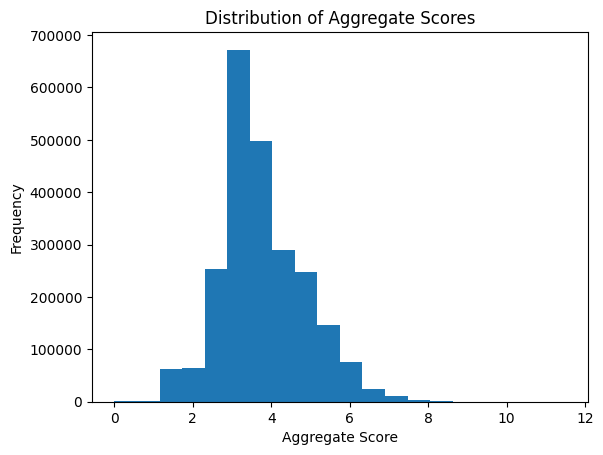

In [10]:
# agg to date, repo_name, and aggregate_score (first)
agg_df = (scorecard_df
    .group_by("scorecard_date", "repo_name")
    .agg(pl.col("aggregate_score").first().alias("aggregate_score"))
)

# plot hisogram of aggregate_score
plt.hist(agg_df["aggregate_score"], bins=20)
plt.xlabel("Aggregate Score")
plt.ylabel("Frequency")
plt.title("Distribution of Aggregate Scores")
plt.show()

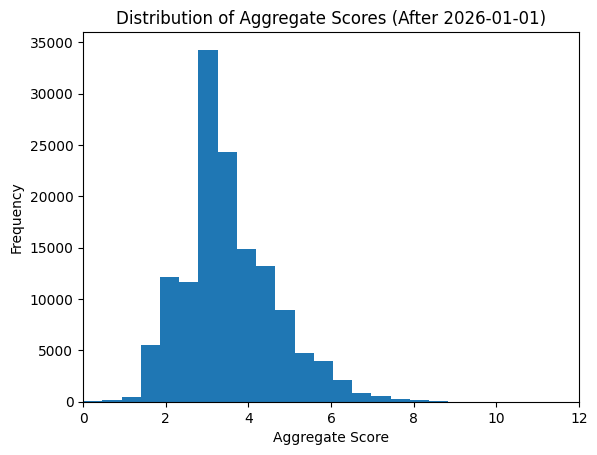

In [11]:

# plot histogram of aggregate_score where date is after 2026-01-01
agg_df_filtered = agg_df.filter(pl.col("scorecard_date") > date(2026, 1, 1))
plt.hist(agg_df_filtered["aggregate_score"], bins=20)
plt.xlim(0, 12)
plt.xlabel("Aggregate Score")
plt.ylabel("Frequency")
plt.title("Distribution of Aggregate Scores (After 2026-01-01)")
plt.show()


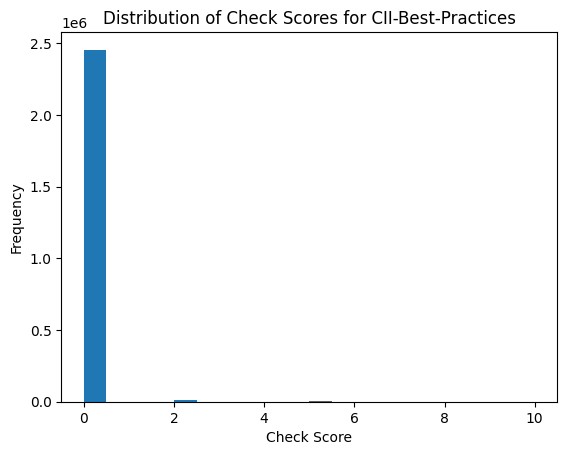

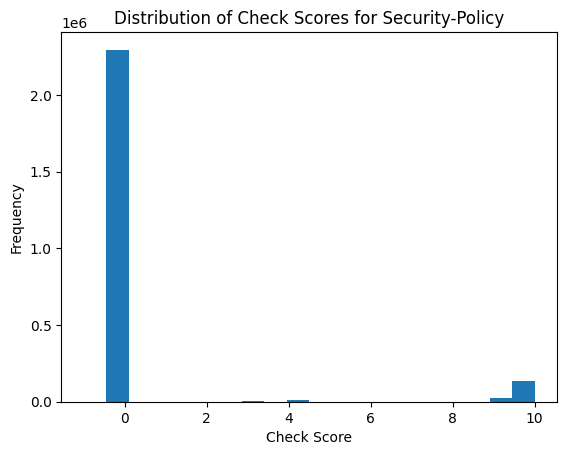

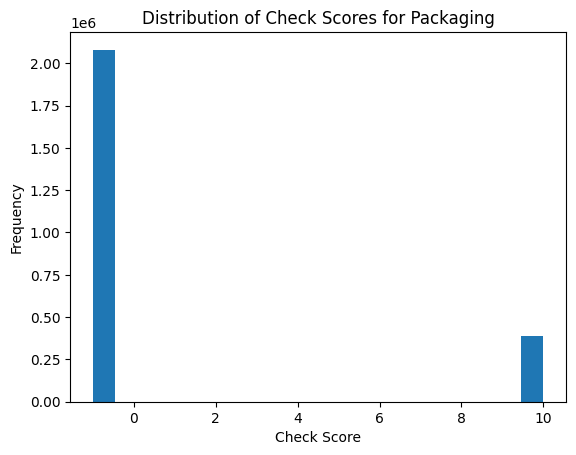

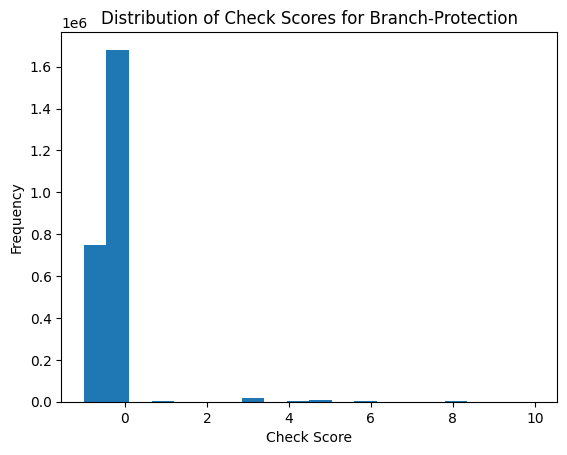

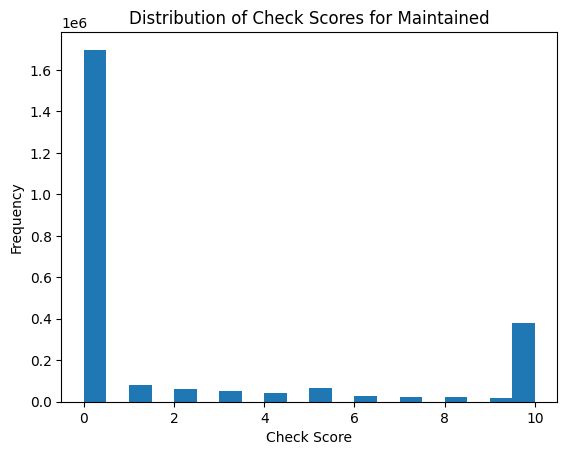

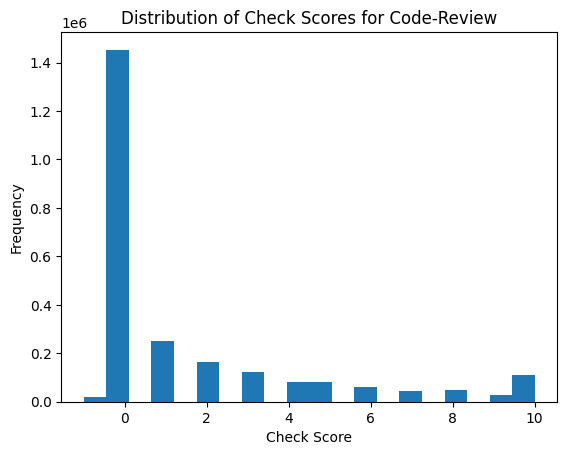

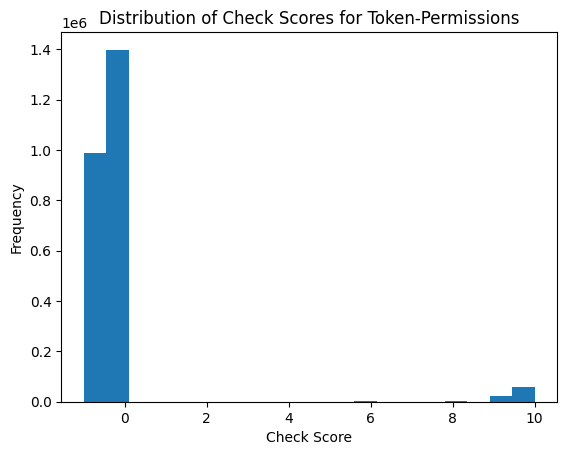

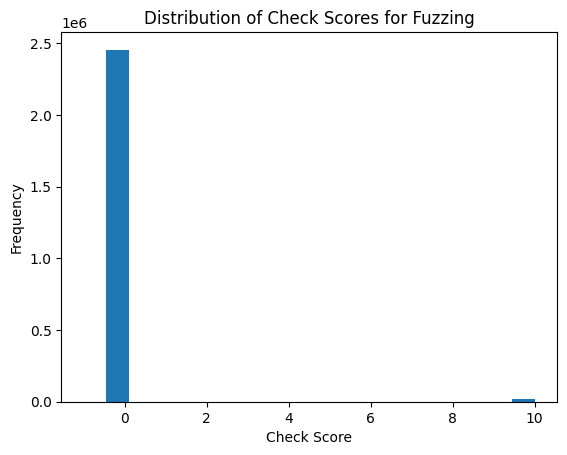

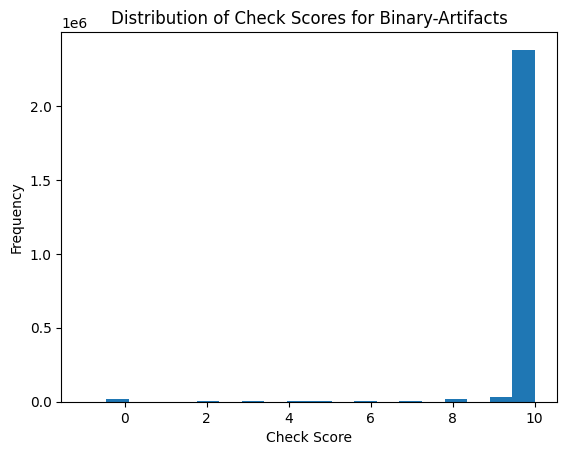

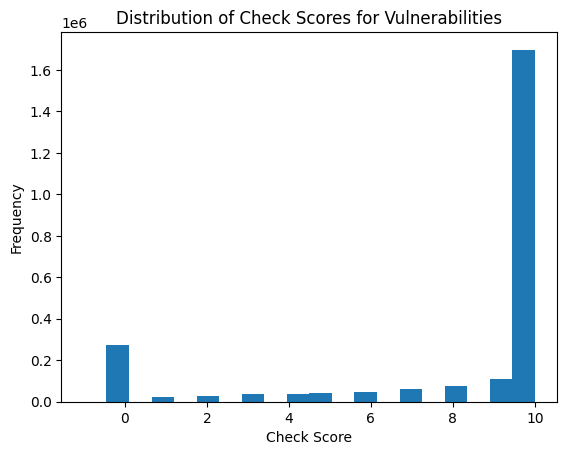

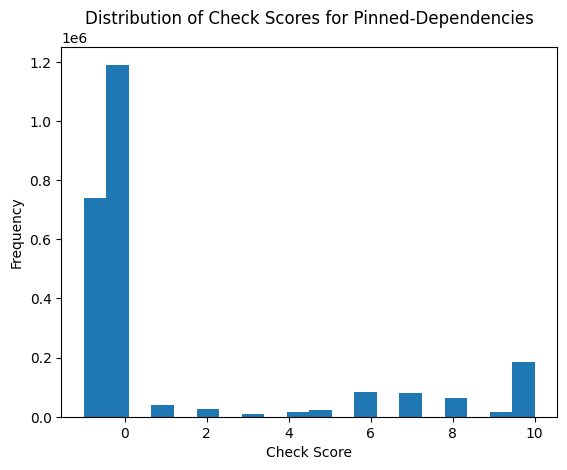

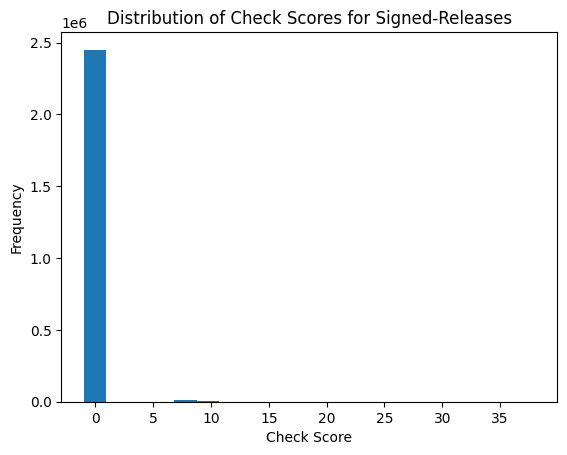

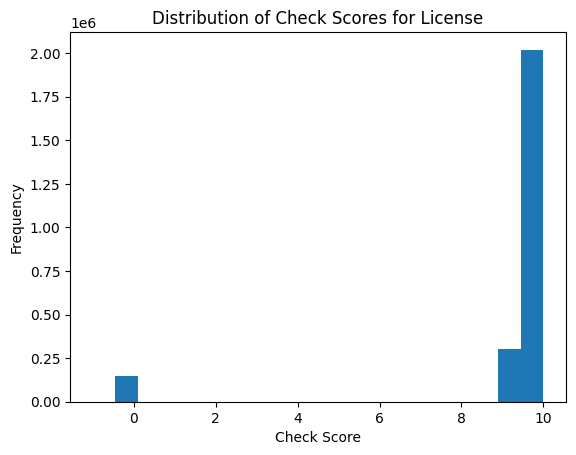

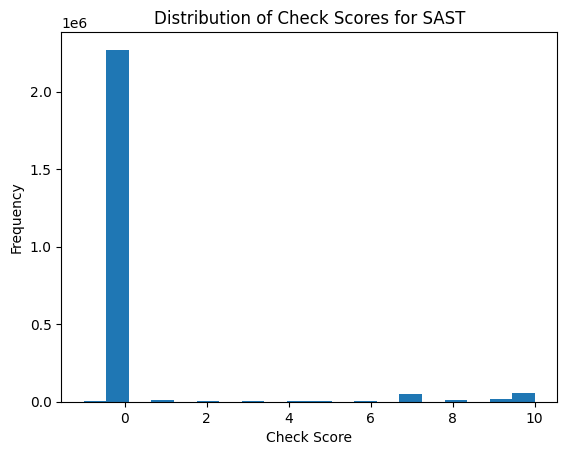

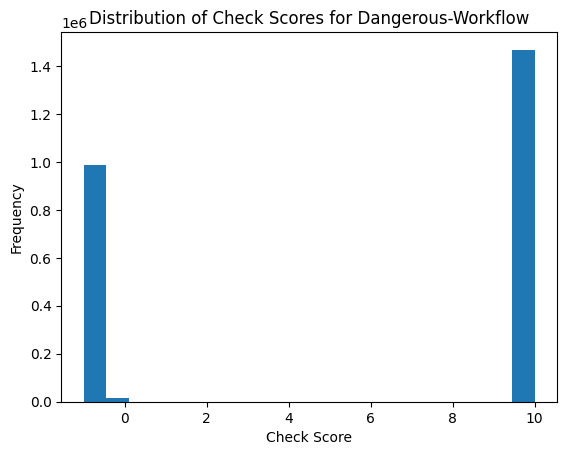

In [12]:
# for check_name, please plot a histogram of the check_score 
for check_name in scorecard_df["check_name"].unique():
    check_df = scorecard_df.filter(pl.col("check_name") == check_name)
    plt.hist(check_df["check_score"], bins=20)
    plt.xlabel("Check Score")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Check Scores for {check_name}")
    plt.show()


In [13]:
librariesio_df = pl.read_parquet("../../data/source_data/librariesio/librariesio.parquet")
librariesio_df.head()

full_name,description,fork,created_at,updated_at,pushed_at,size,stargazers_count,language,has_issues,has_wiki,has_pages,forks_count,open_issues_count,default_branch,subscribers_count,license,contributions_count,has_readme,has_changelog,has_contributing,has_license,has_coc,has_threat_model,has_audit,status,rank,github_contributions_count,github_id
str,str,bool,str,str,str,i64,i64,str,bool,bool,bool,i64,i64,str,i64,str,i64,str,str,str,str,str,str,str,str,i64,i64,str
"""pelican-plugins/image-process""","""Pelican plugin that automates …",false,"""2015-02-06T18:51:48.000Z""","""2025-11-18T08:51:02.632Z""","""2025-11-18T08:50:08.000Z""",10840,58,"""Python""",true,false,false,22,4,"""main""",5,"""AGPL-3.0""",18,"""README.md""","""CHANGELOG.md""","""CONTRIBUTING.md""","""LICENSE""",null,null,null,null,7,18,"""30427628"""
"""lucidrains/rotary-embedding-to…","""Implementation of Rotary Embed…",false,"""2021-06-29T19:05:39.000Z""","""2026-02-08T08:51:21.815Z""","""2025-07-27T01:25:42.000Z""",113,716,"""Python""",true,true,false,63,18,"""main""",11,"""MIT""",5,"""README.md""",null,null,"""LICENSE""",null,null,null,null,14,5,"""381470350"""
"""soulmachine/delimited-protobuf""","""A read/write library for lengt…",false,"""2021-09-23T21:49:18.000Z""","""2021-09-24T23:00:49.034Z""","""2021-09-24T21:16:11.000Z""",13,0,"""Python""",true,true,false,0,0,"""main""",1,"""Apache-2.0""",1,"""README.md""",null,null,"""LICENSE""",null,null,null,null,3,1,"""409752898"""
"""canonical/craft-store""","""Python API to communicate with…",false,"""2021-08-06T11:59:22.000Z""","""2025-10-22T20:17:12.664Z""","""2025-10-21T19:59:15.000Z""",1294,5,"""Python""",true,false,false,19,21,"""main""",5,"""LGPL-3.0""",14,"""README.md""",null,"""CONTRIBUTING.md""","""LICENSE""",null,null,null,null,6,14,"""393363282"""
"""flaskbb/flask-debugtoolbar-war…","""Adds warnings support to flask…",false,"""2018-06-04T03:40:08.000Z""","""2025-01-18T03:14:57.702Z""","""2018-06-13T00:46:42.000Z""",19,2,"""Python""",true,true,false,1,0,"""master""",3,"""MIT""",1,"""README.rst""","""CHANGELOG""",null,"""LICENSE""",null,null,null,null,3,1,"""135967074"""


In [14]:
librariesio_df.shape

(18149, 29)